# Projeto 01 — Análise de Vendas (E-commerce Olist)

**Objetivo:** identificar os produtos, categorias e regiões mais rentáveis de um e-commerce brasileiro, a partir de dados reais (dataset Olist).

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Arquivos necessários (baixe do Kaggle e suba aqui):**
- `olist_orders_dataset.csv`
- `olist_order_items_dataset.csv`
- `olist_products_dataset.csv`
- `olist_customers_dataset.csv`
- `olist_order_payments_dataset.csv`
- `product_category_name_translation.csv`

## 1. Upload dos arquivos

In [1]:
from google.colab import files
uploaded = files.upload()
# Selecione TODOS os 6 arquivos CSV de uma vez na janela que abrir

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving PowerBI_Anderson_Mendonca.xlsx to PowerBI_Anderson_Mendonca.xlsx
Saving product_category_name_translation.csv to product_category_name_translation.csv


## 2. Importar bibliotecas e carregar dados

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

print('Pedidos:', orders.shape)
print('Itens:', order_items.shape)
print('Produtos:', products.shape)
print('Clientes:', customers.shape)
print('Pagamentos:', payments.shape)

Pedidos: (99441, 8)
Itens: (112650, 7)
Produtos: (32951, 9)
Clientes: (99441, 5)
Pagamentos: (103886, 5)


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 3. Juntar as tabelas (merge)

Vamos unir os itens de pedido com pedidos, produtos e clientes para ter uma tabela única com todas as informações necessárias.

In [3]:
df = order_items.merge(orders, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')

print('Shape final:', df.shape)
df.head()

Shape final: (112650, 27)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,4.0,650.0,28.0,9.0,14.0,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2.0,30000.0,50.0,30.0,40.0,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2.0,3050.0,33.0,13.0,33.0,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,1.0,200.0,16.0,10.0,15.0,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,1.0,3750.0,35.0,40.0,30.0,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,garden_tools


## 4. Limpeza inicial dos dados

In [5]:
# Verificar valores nulos nas colunas principais
cols_check = ['price', 'freight_value', 'order_purchase_timestamp',
               'customer_state', 'product_category_name_english']
print(df[cols_check].isnull().sum())

# Converter data
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Considerar apenas pedidos entregues (dados mais confiáveis para análise de vendas)
df_delivered = df[df['order_status'] == 'delivered'].copy()
print('\nPedidos entregues:', df_delivered.shape[0])

price                               0
freight_value                       0
order_purchase_timestamp            0
customer_state                      0
product_category_name_english    1627
dtype: int64

Pedidos entregues: 110197


## 5. Receita total por categoria de produto

In [6]:
receita_categoria = (
    df_delivered.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

receita_categoria

,price
product_category_name_english,
health_beauty,1233131.72
watches_gifts,1166176.98
bed_bath_table,1023434.76
sports_leisure,954852.55
computers_accessories,888724.61
furniture_decor,711927.69
housewares,615628.69
cool_stuff,610204.10
auto,578966.65


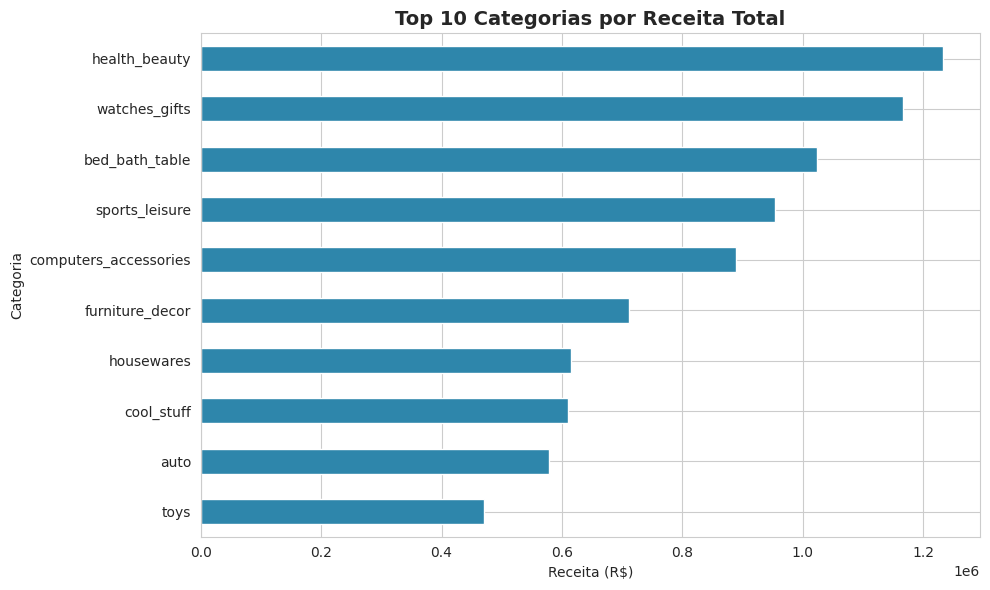

In [7]:
plt.figure(figsize=(10, 6))
receita_categoria.plot(kind='barh', color='#2E86AB')
plt.title('Top 10 Categorias por Receita Total', fontsize=14, fontweight='bold')
plt.xlabel('Receita (R$)')
plt.ylabel('Categoria')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_categorias_receita.png', dpi=120)
plt.show()

## 6. Receita por estado (região)

In [8]:
receita_estado = (
    df_delivered.groupby('customer_state')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

receita_estado

,price
customer_state,
SP,5067633.16
RJ,1759651.13
MG,1552481.83
RS,728897.47
PR,666063.51
SC,507012.13
BA,493584.14
DF,296498.41
GO,282836.70


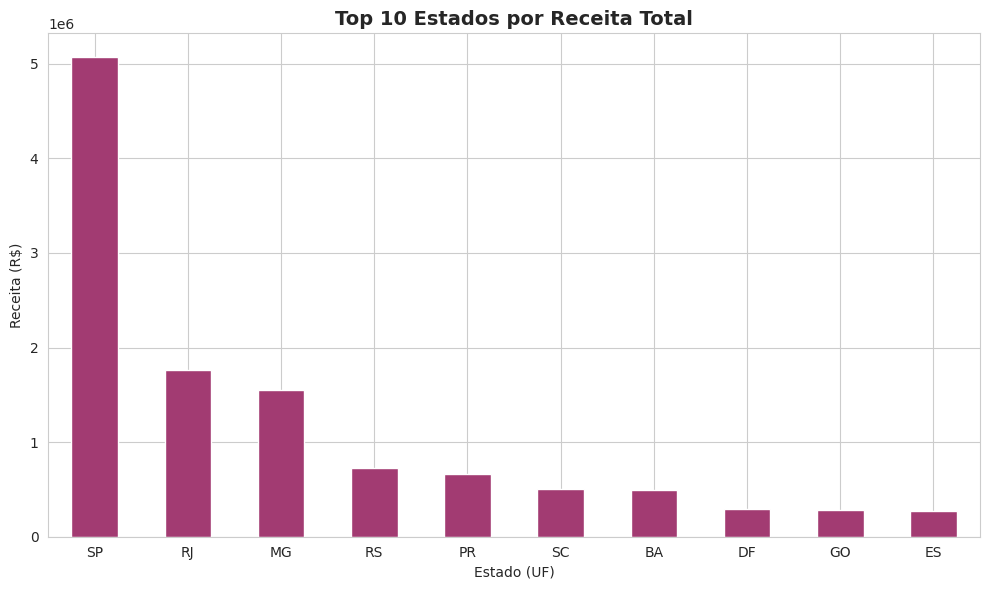

In [9]:
plt.figure(figsize=(10, 6))
receita_estado.plot(kind='bar', color='#A23B72')
plt.title('Top 10 Estados por Receita Total', fontsize=14, fontweight='bold')
plt.xlabel('Estado (UF)')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('top10_estados_receita.png', dpi=120)
plt.show()

## 7. Ticket médio (geral e por categoria)

In [10]:
# Ticket médio geral (valor médio por item vendido)
ticket_medio_geral = df_delivered['price'].mean()
print(f'Ticket médio geral: R$ {ticket_medio_geral:.2f}')

# Ticket médio por pedido (somando itens do mesmo pedido)
ticket_por_pedido = df_delivered.groupby('order_id')['price'].sum()
print(f'Ticket médio por pedido: R$ {ticket_por_pedido.mean():.2f}')

# Ticket médio por categoria (top 10 por receita)
ticket_categoria = (
    df_delivered.groupby('product_category_name_english')['price']
    .mean()
    .loc[receita_categoria.index]
    .sort_values(ascending=False)
)

ticket_categoria

Ticket médio geral: R$ 119.98
Ticket médio por pedido: R$ 137.04


,price
product_category_name_english,
watches_gifts,199.040276
cool_stuff,164.121598
auto,139.847017
health_beauty,130.283330
toys,116.944536
computers_accessories,116.264339
sports_leisure,113.254958
bed_bath_table,93.438762
housewares,90.600249


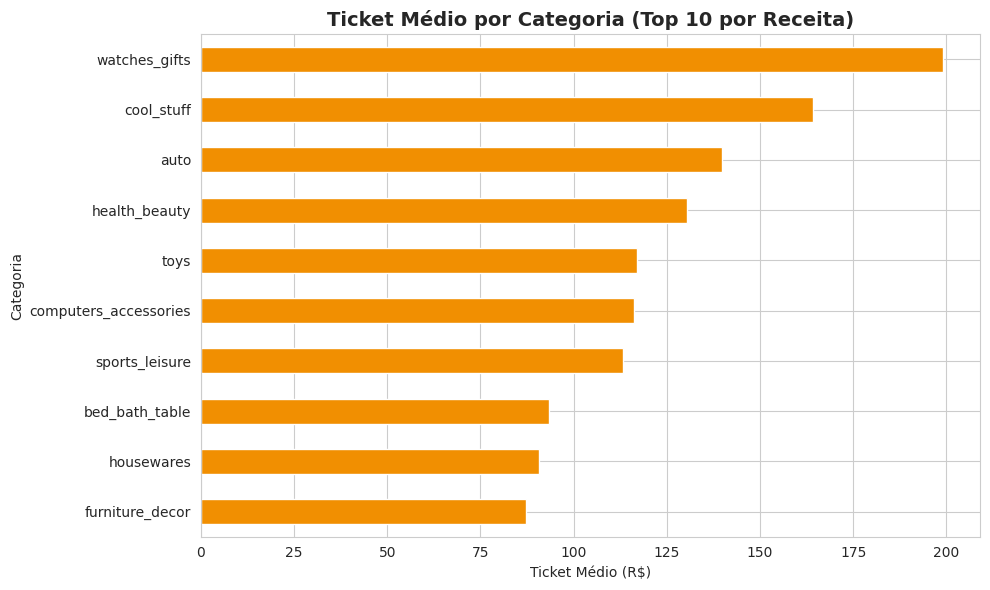

In [11]:
plt.figure(figsize=(10, 6))
ticket_categoria.plot(kind='barh', color='#F18F01')
plt.title('Ticket Médio por Categoria (Top 10 por Receita)', fontsize=14, fontweight='bold')
plt.xlabel('Ticket Médio (R$)')
plt.ylabel('Categoria')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('ticket_medio_categoria.png', dpi=120)
plt.show()

## 8. Sazonalidade — vendas por mês

In [12]:
vendas_mensais = (
    df_delivered.groupby('order_month')['price']
    .sum()
    .sort_index()
)

vendas_mensais

,price
order_month,
2016-09,134.97
2016-10,40325.11
2016-12,10.90
2017-01,111798.36
2017-02,234223.40
2017-03,359198.85
2017-04,340669.68
2017-05,489338.25
2017-06,421923.37


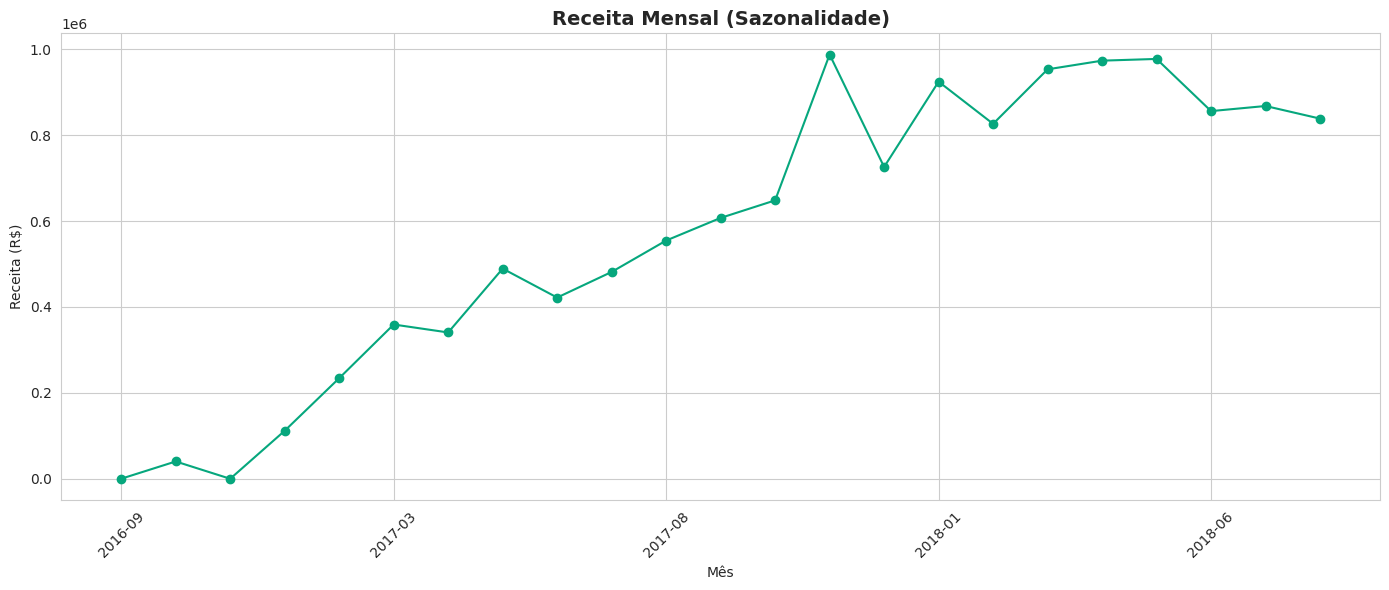

In [13]:
plt.figure(figsize=(14, 6))
vendas_mensais.plot(kind='line', marker='o', color='#06A77D')
plt.title('Receita Mensal (Sazonalidade)', fontsize=14, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('vendas_mensais.png', dpi=120)
plt.show()

## 9. Top 10 produtos mais vendidos (em quantidade)

In [14]:
top_produtos = (
    df_delivered.groupby('product_id')
    .agg(qtd_vendida=('order_item_id', 'count'), receita_total=('price', 'sum'), categoria=('product_category_name_english', 'first'))
    .sort_values('qtd_vendida', ascending=False)
    .head(10)
)

top_produtos

,qtd_vendida,receita_total,categoria
product_id,,,
aca2eb7d00ea1a7b8ebd4e68314663af,520,37104.30,furniture_decor
422879e10f46682990de24d770e7f83d,484,26577.22,garden_tools
99a4788cb24856965c36a24e339b6058,477,42049.66,bed_bath_table
389d119b48cf3043d311335e499d9c6b,390,21336.79,garden_tools
368c6c730842d78016ad823897a372db,388,21056.80,garden_tools
53759a2ecddad2bb87a079a1f1519f73,373,20387.20,garden_tools
d1c427060a0f73f6b889a5c7c61f2ac4,332,45620.56,computers_accessories
53b36df67ebb7c41585e8d54d6772e08,321,37454.63,watches_gifts
154e7e31ebfa092203795c972e5804a6,274,6173.26,health_beauty


## 10. Frete médio por estado (custo logístico)

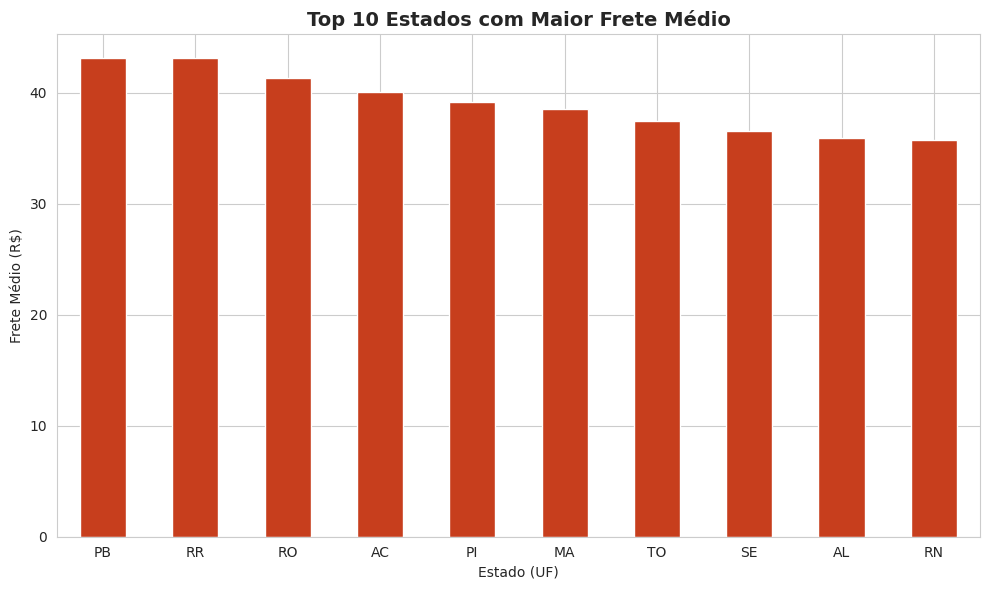

In [15]:
frete_estado = (
    df_delivered.groupby('customer_state')['freight_value']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
frete_estado.plot(kind='bar', color='#C73E1D')
plt.title('Top 10 Estados com Maior Frete Médio', fontsize=14, fontweight='bold')
plt.xlabel('Estado (UF)')
plt.ylabel('Frete Médio (R$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('frete_medio_estado.png', dpi=120)
plt.show()

## 11. Resumo — Principais números

In [16]:
print('='*50)
print('RESUMO GERAL')
print('='*50)
print(f'Receita total (pedidos entregues): R$ {df_delivered["price"].sum():,.2f}')
print(f'Total de pedidos entregues: {df_delivered["order_id"].nunique():,}')
print(f'Ticket médio por pedido: R$ {ticket_por_pedido.mean():.2f}')
print(f'Categoria com maior receita: {receita_categoria.index[0]}')
print(f'Estado com maior receita: {receita_estado.index[0]}')
print(f'Mês com maior receita: {vendas_mensais.idxmax()}')

RESUMO GERAL
Receita total (pedidos entregues): R$ 13,221,498.11
Total de pedidos entregues: 96,478
Ticket médio por pedido: R$ 137.04
Categoria com maior receita: health_beauty
Estado com maior receita: SP
Mês com maior receita: 2017-11


## 12. Insights

Depois de rodar todas as células acima, escreva os 5 insights com base nos resultados reais que você obteve:

1. **Categoria líder:** a categoria `health_beauty` (saúde e beleza) lidera
   em receita, representando R$ 1.233.131,72 — isso indica que produtos
   dessa categoria têm alta demanda e margem relevante, sendo uma
   oportunidade de priorizar estoque, variedade de produtos e campanhas
   de marketing voltadas a esse público.

2. **Concentração regional:** o estado `SP` concentra a maior parte das
   vendas (R$ 5.067.633,16), bem acima dos demais estados — isso indica
   que campanhas de marketing e estratégias de logística (centros de
   distribuição, prazos de entrega) deveriam priorizar essa região, já
   que é onde está a maior base de clientes.

3. **Ticket médio:** o ticket médio por pedido é de R$ 137,04, o que
   mostra que o e-commerce tem um perfil de compras de valor médio/baixo
   — uma oportunidade seria criar estratégias de upsell e cross-sell
   (ex: "compre junto") para aumentar esse valor médio por pedido.

4. **Sazonalidade:** o mês de **novembro** apresentou o pico de vendas,
   possivelmente relacionado à Black Friday — um indicativo de que
   campanhas sazonais e reforço de estoque devem ser planejados com
   antecedência para essa data.

5. **Frete:** os estados PB (Paraíba) e RR (Roraima) têm o frete médio mais
   alto, em torno de R$ 43,00 — bem acima da média nacional. Isso pode
   impactar negativamente a decisão de compra de clientes dessas regiões,
   já que o frete representa uma parcela significativa do valor do produto.
   Uma oportunidade seria negociar tarifas regionais com transportadoras
   ou criar promoções de frete grátis específicas para esses estados,
   aumentando a competitividade nessas regiões.

## 13. Exportar gráficos para o GitHub

Os arquivos `.png` gerados (top10_categorias_receita.png, top10_estados_receita.png, etc.) ficam salvos no ambiente do Colab. Baixe-os clicando no ícone de pasta (lateral esquerda) > botão direito no arquivo > Download.

**Próximos passos:**
1. Baixe este notebook (`File > Download > Download .ipynb`)
2. Baixe os gráficos `.png` gerados
3. Crie um repositório no GitHub chamado `analise-vendas-ecommerce`
4. Suba o notebook, os gráficos e crie um `README.md` com os 5 insights